### Google Drive Integration
Mounting the Google Drive directory (`/content/drive`) directly into the Colab runtime establishes a secure bridge to cloud storage. This function is required so the script can locate and read the dataset file natively, saving manual file uploads every time a new session starts.

In [335]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Library Initialization and Reproducibility
This section imports essential tools like TensorFlow, Pandas, and Scikit-learn, while locking the random seed to 42. Importing all of these packages is necessary because Python does not have built-in tools for deep learning or machine learning evaluation by default. Specifically, TensorFlow is imported because its function is to provide the tensor operations, automatic differentiation, and neural network layers needed to build, compile, and train deep learning models efficiently. Pandas is imported because its function is to read, filter, and manage data tables easily. Scikit-learn is imported because its function is to handle data splitting via train_test_split and compute evaluation scores like F1-score and accuracy. Furthermore, setting the random seed ensures the model starts with identical random weights every time, making test results consistent.

In [336]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Data Ingestion and Preprocessing Pipeline
This part loads the CSV file, converts natural language text into number tokens, and limits each ticket to a fixed length of 20 words using padding or truncation. Then, Scikit-learn's split function divides the data into 70% for training, 15% for validation, and 15% for testing. This pipeline is necessary because neural networks cannot process raw text strings directly; they require numerical arrays and uniform matrix sizes to compute properly.

In [337]:
# ==========================================
# 1. LOAD & PREPROCESS CSV DATA
# ==========================================
CSV_FILEPATH = '/content/drive/MyDrive/IT_Support_Tickets_Dataset.csv'
MAX_LEN = 20                # Fixed sequence length (padded/truncated)
MAX_VOCAB_SIZE = 1000       # Vocabulary size limit

# Load CSV
df = pd.read_csv(CSV_FILEPATH)

# Basic Tokenizer & Vocabulary Builder
def build_vocab(texts, max_vocab_size):
    words = [word.lower() for text in texts for word in str(text).split()]
    word_counts = Counter(words)
    # Reserve index 0 for padding (<PAD>) and 1 for unknown tokens (<UNK>)
    most_common = word_counts.most_common(max_vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len):
    tokens = str(text).lower().split()
    seq = [vocab.get(token, 1) for token in tokens]
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))  # Pad with 0
    else:
        seq = seq[:max_len]              # Truncate
    return seq

# Build vocab and encode text
vocab = build_vocab(df['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df['label'].values)

num_classes = len(np.unique(y_data))

# Dataset Partitioning (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

### Hyperparameter Configuration and System Architecture
All main settings are grouped inside the CONFIG dictionary, while Keras builds the neural network structure layer by layer. An Embedding layer processes word tokens, followed by a global average pooling layer, a dense hidden layer with ReLU activation, a dropout layer to prevent memorization, and a final softmax output layer for classification. This setup gives the model the exact mathematical structure required to learn patterns from support tickets.

In [338]:
# ==========================================
# 2. HYPERPARAMETER CONFIGURATION
# ==========================================
CONFIG = {
    "run_id": "EXP-11",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 64,
    "epochs": 10,
    "optimizer_type": "Adam",
    "dropout_rate": 0.1
}

# ==========================================
# 3. KERAS SEQUENTIAL ARCHITECTURE
# ==========================================
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization)
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Model Compilation and Operational Training Loop
This section pairs the model with the Adam optimizer and the sparse categorical cross-entropy loss function before executing model.fit(). This compilation and training loop acts as the learning engine, allowing the network to process data in batches, calculate errors through backpropagation, and update internal weights across multiple epochs.

In [339]:
# ==========================================
# 4. OPTIMIZER & COMPILATION
# ==========================================
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 5. THE OPERATIONAL LOOP (FIT & EVALUATE)
# ==========================================
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print("\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_50 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_50     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-11 ---
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.3333 - loss: 1.0975 - val_accuracy: 0.4444 - val_loss: 1.0870
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6032 - loss: 1.0727 - val_accuracy: 0.5185 - val_loss: 1.0605
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8413 - loss: 1.0286 - val_accuracy: 0.6667 - val_loss: 1.0178
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9444 - loss: 0.9570 - val_accuracy: 0.7778 - val_loss: 0.9572
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9921 - loss: 0.8625 - val_accuracy: 0.8148 - val_loss: 0.8789
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9921 - loss: 0.7466 - val_accuracy: 0.7778 - val_loss: 0.7905
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.6146 - val_accuracy: 0.7778 - val_loss: 0.7034
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.4813 - v

### Performance Monitoring and Visual Analysis
Using the Matplotlib library, this block draws a line graph comparing training loss against validation loss across every epoch. Matplotlib is used because Python lacks built-in chart creation tools, and this visualization is needed to easily check if the model is generalizing well or starting to overfit.

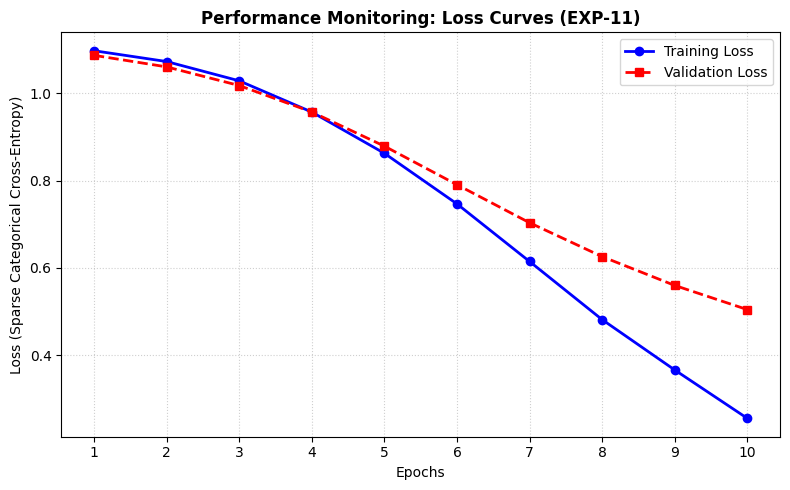

In [340]:
# ==========================================
# 6. GENERATE LOSS CURVES CHART
# ==========================================
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()


In [341]:
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Get model predictions on validation data
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# If y_val is one-hot encoded, convert to class indices using np.argmax(y_val, axis=1)
# If y_val is already sparse/integer encoded, use y_val directly:
precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_val, y_pred, average='weighted', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Precision: 0.8321
Recall: 0.8148
